## Challenge 02: Edge Detection

### Description
Edge detection plays a key role in finding wall cracks because it helps highlight the exact 
locations where the wall surface changes suddenly. When a wall is smooth, the pixel values 
in an image change gradually. However, a crack creates a sharp change in intensity (from the 
wall surface to the dark line of the crack). Edge detection algorithms are designed to detect 
these sudden changes, so they make cracks appear as clear, thin lines.

### challenge
Apply basic edge detection techniques to detect object boundaries. Compare results using 
different operators such as Sobel, Prewitt, or Canny
For this challenge I take a photo of a wall with cracks. then Process the image using 
different edge detection techniques to extract the cracks.

### Part i — Libraries:

 - **cv2 (OpenCV)**: The computer vision library used for reading images, converting color spaces, applying blur filters, and running all four edge detection algorithms Sobel, Prewitt through filter2D, Laplacian, and Canny.
- **numpy as np**: Used to manually define the Prewitt kernel matrices as 2D arrays.
- **matplotlib.pyplot as plt**: Used to display and processed images in a grid layout for easy and clear visualization.

### Part ii — User-Defined Functionses:
**plot_image(image, title)**  
A function that include three matplotlib calls:imshow, title, and axis('off') This fiction is used to  prevents repetitive code when displaying multiple images in subplots.

### Part iii — Image Conversion:
- **cv2.COLOR_BGR2RGB** used because OpenCV reads images in BGR by default, but matplotlib expects RGB. so, without this conversion red and blue channels would appear swapped in the plot.

- **cv2.COLOR_BGR2GRAY** it converts the image to a grayscale image. used for edge detection algorithms because it works on intensity gradients, which require a single numerical value per pixel.it the standard pre-processing step before applying any edge detection filter.

### Part iv — Image Preparation:
Before applying edge detection, the grayscale image is smoothed using Gaussian Blur.

using Gaussian Blur if the image contains noise, because it produce large gradients and it may falsely detected as edges. Gaussian blur smooths out this noise by averaging each pixel with its neighbors using a weighted Gaussian kernel.

### Part v — Code Explanation:
### Part 1 —DIP Techniques Used:

**1.  Prewitt** : Prewitt it is a differential operator for image edge detection, its principle is to realize edge detection by using the difference generated by the gray value of pixels in a specific area . Prewitt operator used 3×3 template to calculate the pixel values in the region.**the implemention in the code:** first the kernels are defined manually using np.array() and then applied with cv2.filter2D(),then the cv2.convertScaleAbs() is applied to both results before combining with cv2.addWeighted() to produce the final gradient map.

**2. Sobel** : Sobel is a discrete differential operator for edge detection , it combines Gaussian smoothing with differential derivation.**the implemention in the code:** first Sobel method applies two 3×3 gradient kernels one for horizontal edges and one for vertical edges ,then the cv2.convertScaleAbs() is applied to both results before combining with cv2.addWeighted() to produce the final gradient map.

**3. Laplacian** :Laplacian detects edges using the second derivative of the image intensity.**the implemention in the code:** first apply gussian filter becasue Laplacian is sensitive to noise then the Laplacian method ,then the cv2.convertScaleAbs() is applied to the results.

**4. Canny** : Canny is one of the most popular edge-detection methods in use today because it is so robust and flexible.It is a multi-step algorithm:
1. Noise Reduction
2. Calculating Intensity Gradient of the Image
3. Suppression of False Edges
4. Hysteresis Thresholding

### Part 2 —Additional Methods:
- cv2.GaussianBlur() : smooths out this noise
- cv2.convertScaleAbs() :converts float/signed images to uint8 for display after gradient computation
- cv2.addWeighted() :combines x and y Prewitt and Sobel gradients with equal weights 

### Part 3 — Difficulty Faced:
The difficulty was tuning the Canny thresholds for the image in this challenge.Low threshold values (15, 100) were chosen after testing higher values like (50, 150) which caused parts of the crack to disappear due to insufficient gradient strength.








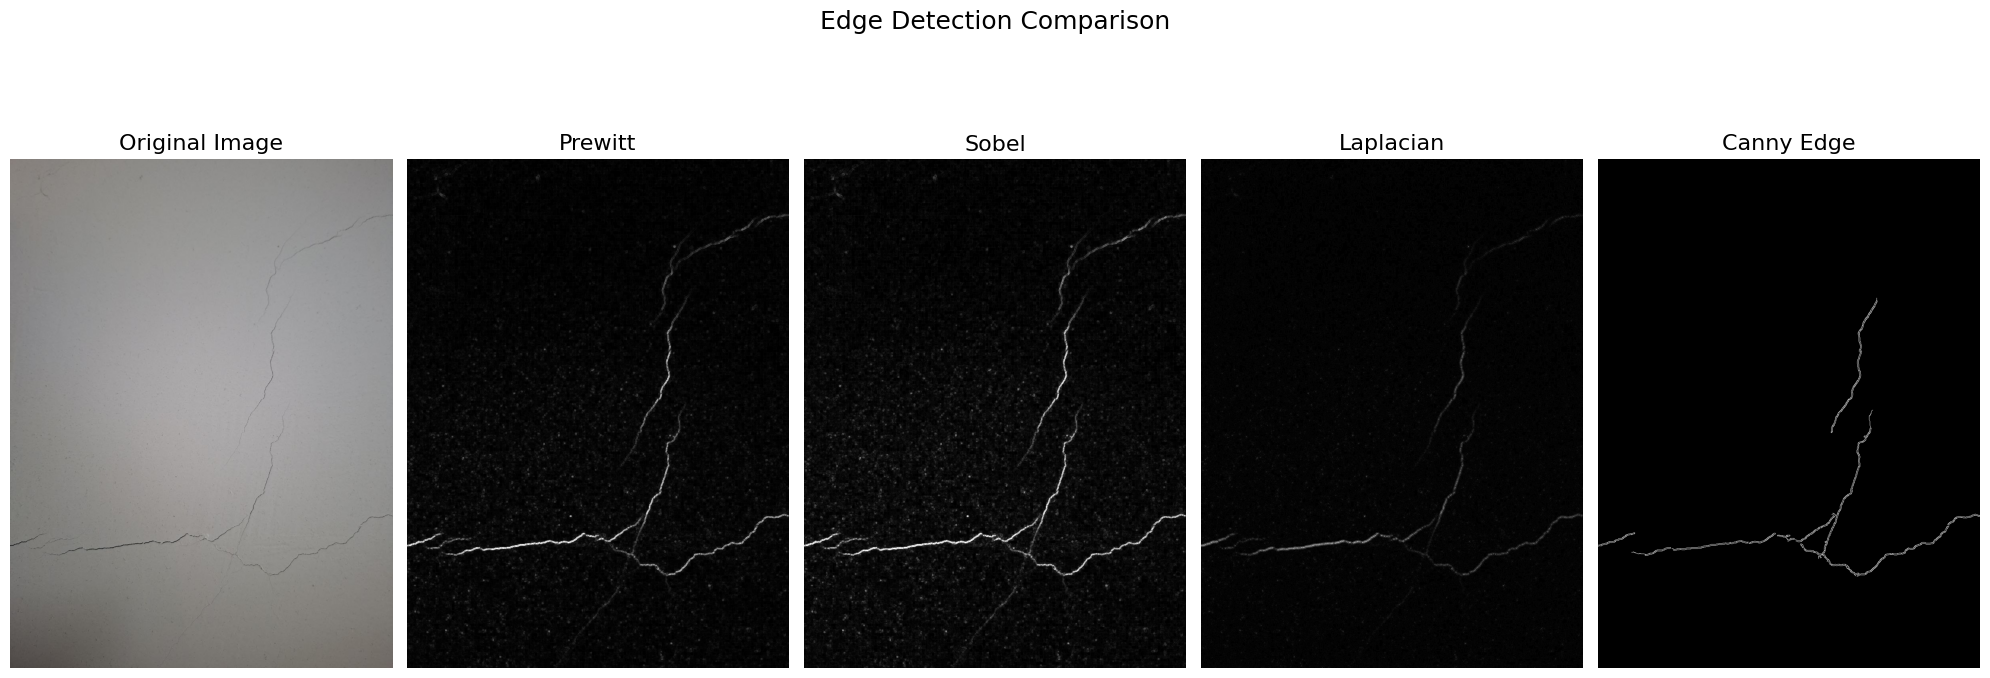

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# function: to display image with title, axes hidden
def plot_image(image, title):
    plt.imshow(image, cmap='gray'), plt.title(title, size=16), plt.axis('off')

# Loading Image 
image = cv2.imread('images/challenge2.jpg')
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   

# Grayscale Conversion 
grayImage = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Image Preparation: Gaussian Blur
blurred = cv2.GaussianBlur(grayImage, (5, 5), 0)


# 1. Prewitt Edge Detection 
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])   # horizontal kernel
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])   # vertical kernel

x = cv2.filter2D(grayImage, cv2.CV_16S, kernelx)
y = cv2.filter2D(grayImage, cv2.CV_16S, kernely)

absX = cv2.convertScaleAbs(x)
absY = cv2.convertScaleAbs(y)

prewitt = cv2.addWeighted(absX,1,absY,1, 0)

# 2. Sobel Edge Detection
x = cv2.Sobel(grayImage, cv2.CV_16S, 1, 0) 
y = cv2.Sobel(grayImage, cv2.CV_16S, 0, 1) 

SabsX = cv2.convertScaleAbs(x)
SabsY = cv2.convertScaleAbs(y)

Sobel = cv2.addWeighted(SabsX,1,SabsY,1,0) 

# 3. Laplacian Edge Detection 
laplacian = cv2.Laplacian(blurred, cv2.CV_16S, ksize=3)
laplacian_result= cv2.convertScaleAbs(laplacian)

# 4. Canny Edge Detection 
canny = cv2.Canny(blurred, 15, 100, 3, L2gradient=True)

# Display Results 
plt.figure(figsize=(20, 8))

plt.subplot(151), plot_image(img, 'Original Image')
plt.subplot(152), plot_image(prewitt,'Prewitt')
plt.subplot(153), plot_image(Sobel, 'Sobel')
plt.subplot(154), plot_image(laplacian_result, 'Laplacian')
plt.subplot(155), plot_image(canny,'Canny Edge')

plt.suptitle('Edge Detection Comparison',fontsize=18)
plt.tight_layout()
plt.show()


## Part vi — Comparison of Techniques

- **Sobel** successfully highlights the crack as a bright ridge. The crack is clearly visible but not perfectly isolated.

- **Prewitt** produces results visually similar to Sobel,but the response is slightly less pronounced on strong edge.

- **Laplacian** is more sensitive to noise this causes more scattered background detections compared to Sobel and Prewitt. The crack is still visible, but it requires a great thresholding to isolate it from the noise.

- **Canny** produces the clearest result for the challange . The min thresholding eliminates most false detections on the smooth wall, and the max thresholding thins the crack to a clean line. This makes Canny the most suitable technique for structural crack detection.
